In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
import statsmodels.api as sm


## 1- Chargement et préparation des données

In [119]:
data = pd.read_excel('C:/Users/lenovo/Desktop/Analyse/data.xlsx', engine='openpyxl', sheet_name='Data')
data['Mois'] = pd.to_datetime(data['Mois'], format='%m-%Y')
data = data.set_index('Mois')
data = data.sort_index()
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 320 entries, 2000-01-01 to 2026-08-01
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EUR_DZD            320 non-null    float64
 1   USD_DZD            320 non-null    float64
 2   IPC_DZ             290 non-null    float64
 3   IPC_US             290 non-null    float64
 4   Brent              320 non-null    float64
 5   Taux_directeur_BA  114 non-null    float64
 6   USD_EUR            320 non-null    float64
 7   RSV                97 non-null     float64
dtypes: float64(8)
memory usage: 22.5 KB


In [120]:
sources = pd.read_excel('C:/Users/lenovo/Desktop/Analyse/data.xlsx', engine='openpyxl', sheet_name='Source')
sources['Premier_mois'] = pd.to_datetime(sources['Premier_mois']).dt.strftime("%m-%Y")
sources['Dernier_mois'] = pd.to_datetime(sources['Dernier_mois']).dt.strftime("%m-%Y")
sources

,Code,Indicateur,Source,Premier_mois,Dernier_mois
0,EUR_DZD,Moyenne mensuelle du taux de change EUR/DZD,Banque d'Algérie,01-2000,08-2026
1,USD_DZD,Moyenne mensuelle du taux de change USD/DZD,Banque d'Algérie,01-2000,08-2026
2,IPC_DZ,Indice des prix à la consommation en Algerie,Banque d'Algérie,01-2002,02-2026
3,IPC_US,Indice des prix à la consommation en US,U.S. Bureau of Labor Statistics,01-2002,02-2026
4,Brent,Moyenne Mensuelle du prix Spot du baril brent ...,U.S. Energy Information Administration,01-2000,08-2026
5,Taux_directeur,Taux directeur de la Banque d'Algérie,Banque d'Algérie,03-2017,08-2026
6,USD_EUR,Parité USD/EUR,BCE (Banque Centrale Européenne) (4F0),01-2000,08-2026
7,RSV,Réserves officielles de change y compris DTS (...,Banque d'Algérie,12-2015,12-2023


## 2. Matrices de corrélation 

Les corrélations calculées directement sur les séries en niveaux sont trompeuses. Deux séries qui suivent chacune une tendance (hausse ou baisse sur la période) afficheront mécaniquement une corrélation forte, même si elles n'ont aucun lien économique réel.

Ces matrices sont présentées ici uniquement pour illustrer le piège, avant correction.

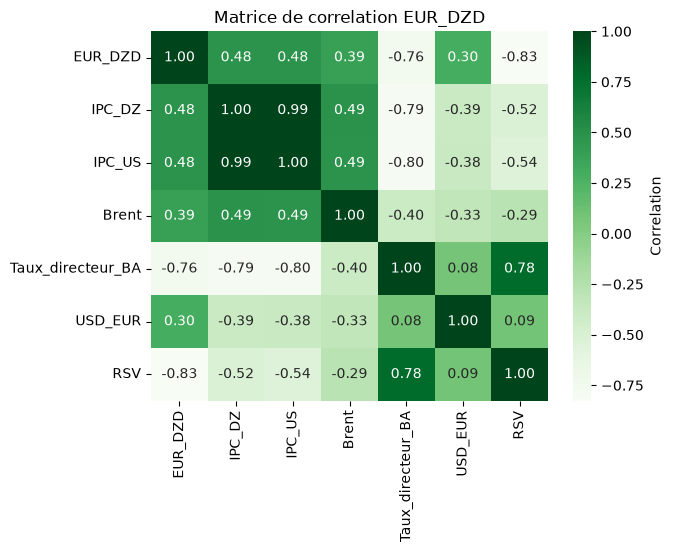

In [142]:
df = data.loc['2017-01':].copy()
correlation_matrix_eur = df.drop(['USD_DZD'], axis=1).corr()
sns.heatmap(correlation_matrix_eur, annot=True, cmap='Greens', fmt='.2f', annot_kws={"size": 10}, cbar_kws={"label": "Correlation"})
plt.title('Matrice de correlation EUR_DZD')
plt.show()


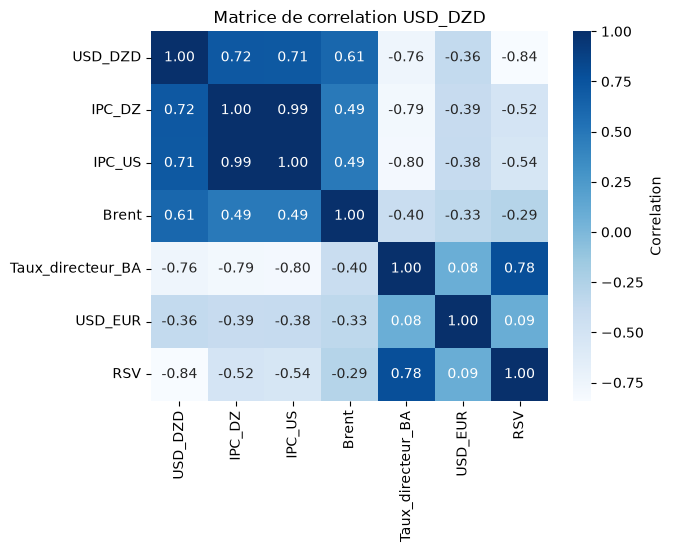

In [143]:
correlation_matrix_usd = df.drop(['EUR_DZD'], axis=1).corr()
sns.heatmap(correlation_matrix_usd, annot=True, cmap='Blues', fmt='.2f', annot_kws={"size": 10}, cbar_kws={"label": "Correlation"})
plt.title('Matrice de correlation USD_DZD')
plt.show()


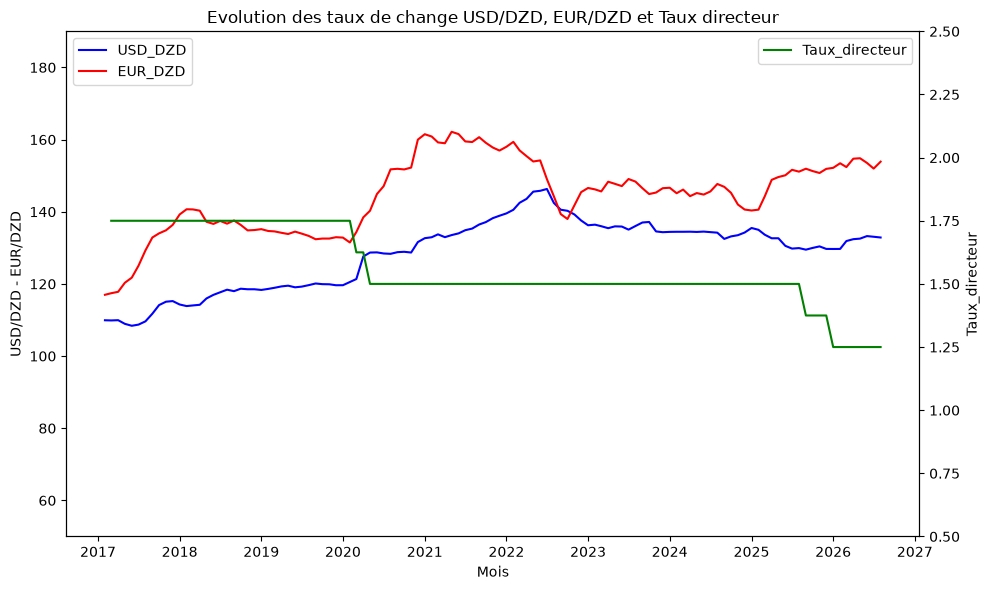

In [ ]:

fig, ax1 = plt.subplots(figsize=(10, 6))
data_graph1 = data[data.index >= '2017-02-01']  

ax1.plot(data_graph1.index, data_graph1['USD_DZD'],
         label='USD_DZD', color='blue')

ax1.plot(data_graph1.index, data_graph1['EUR_DZD'],
         label='EUR_DZD', color='red')

ax1.set_ylim(50, 190)
ax1.set_xlabel('Mois')
ax1.set_ylabel('USD/DZD - EUR/DZD')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()

ax2.plot(data_graph1.index, data_graph1['Taux_directeur_BA']*50,
         label='Taux_directeur', color='green')

ax2.set_ylim(0.5, 2.5)
ax2.set_ylabel('Taux_directeur')
ax2.legend(loc='upper right')

plt.title('Evolution des taux de change USD/DZD, EUR/DZD et Taux directeur')
plt.tight_layout()
plt.show()

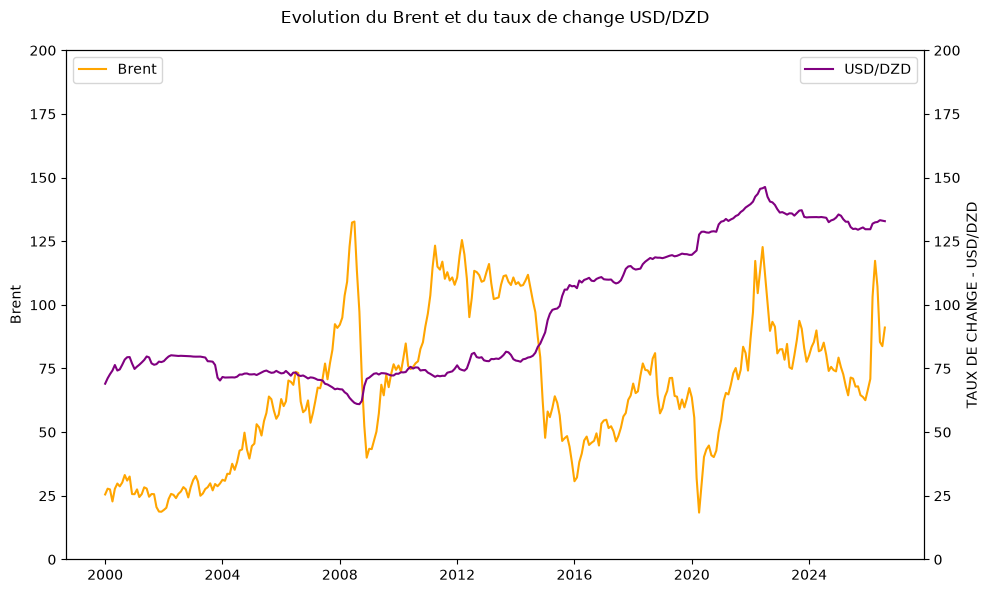

In [ ]:
data_graph2 = data

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(data_graph2.index, data_graph2['Brent'], label='Brent', color='orange')
ax1.set_ylabel('Brent')
ax1.legend(loc='upper left')
ax1.set_ylim(0, 200)

ax2 = ax1.twinx()
ax2.plot(data_graph2.index, data_graph2['USD_DZD'], label='USD/DZD', color='purple')
ax2.set_ylabel('TAUX DE CHANGE - USD/DZD')
ax2.legend(loc='upper right')
ax2.set_ylim(0, 200)
fig.suptitle('Evolution du Brent et du taux de change USD/DZD')
plt.tight_layout()

## 3. Correction : matrices de corrélation sur les *variations mensuelles*

Pour éliminer l'artefact des tendances communes, toutes les séries sont transformées en **variations mensuelles** (`pct_change()` pour les niveaux, `diff()` pour les taux et indices déjà exprimés en pourcentage).

Cette transformation rend les séries stationnaires (elles oscillent autour de zéro) et permet d'identifier de véritables co-mouvements contemporains.

**Données utilisées** : période 2017–2023, variables disponibles sur l'ensemble de la fenêtre.

> **Conclusion** : la seule vraie corrélation contemporaine avec l'USD/DZD est celle des réserves de change (RSV = −0,35). Quand les réserves baissent, la Banque d'Algérie dispose de moins de marges pour soutenir le dinar, qui se déprécie.

In [139]:
df = df.loc['2017-01':'2023-12'].copy()

df['diff_infl'] = df['IPC_DZ'].pct_change(12) - df['IPC_US'].pct_change(12)

df['Taux_directeur_BA'] = df['Taux_directeur_BA'].ffill()

df = df.dropna()

variations = df[['USD_DZD', 'EUR_DZD', 'Brent', 'RSV']].pct_change()

variations['Taux_directeur_BA'] = df['Taux_directeur_BA'].diff()

variations['diff_infl'] = df['diff_infl'].diff()

variations = variations.dropna()

print(variations.shape)
print(variations.describe().round(4))



(59, 6)
       USD_DZD  EUR_DZD    Brent      RSV  Taux_directeur_BA  diff_infl
count  59.0000  59.0000  59.0000  59.0000            59.0000    59.0000
mean    0.0022   0.0015   0.0152  -0.0018            -0.0001     0.0006
std     0.0100   0.0156   0.1456   0.0215             0.0005     0.0088
min    -0.0264  -0.0343  -0.4258  -0.0281            -0.0025    -0.0185
25%    -0.0016  -0.0062  -0.0614  -0.0210             0.0000    -0.0066
50%     0.0024  -0.0012   0.0275  -0.0002             0.0000    -0.0001
75%     0.0063   0.0084   0.0760   0.0095             0.0000     0.0080
max     0.0515   0.0509   0.5985   0.0520             0.0000     0.0202


| Variable | Moyenne | Std | Min | Max | Interprétation |
|---|---|---|---|---|---|
| USD_DZD | +0,24 %/mois | 0,95 % | −2,64 % | +5,15 % | Dépréciation lente et régulière du dinar |
| EUR_DZD | +0,07 %/mois | 1,48 % | −3,43 % | +5,09 % | Plus volatile car dépend aussi de l'EUR/USD |
| Brent | +1,21 %/mois | 13,9 % | **−42,6 %** | +59,9 % | Choc Covid visible (min = avril 2020) |
| RSV | −0,43 %/mois | 2,09 % | −2,81 % | +5,20 % | Tendance baissière des réserves sur la période |
| Taux_directeur_BA | ≈ 0 | 0,04 % | −0,25 % | 0 % | Variable en escalier, quasi nulle chaque mois |
| diff_infl | ≈ 0 | 0,89 % | −1,85 % | +2,02 % | Différentiel d'inflation stable, peu de signal |



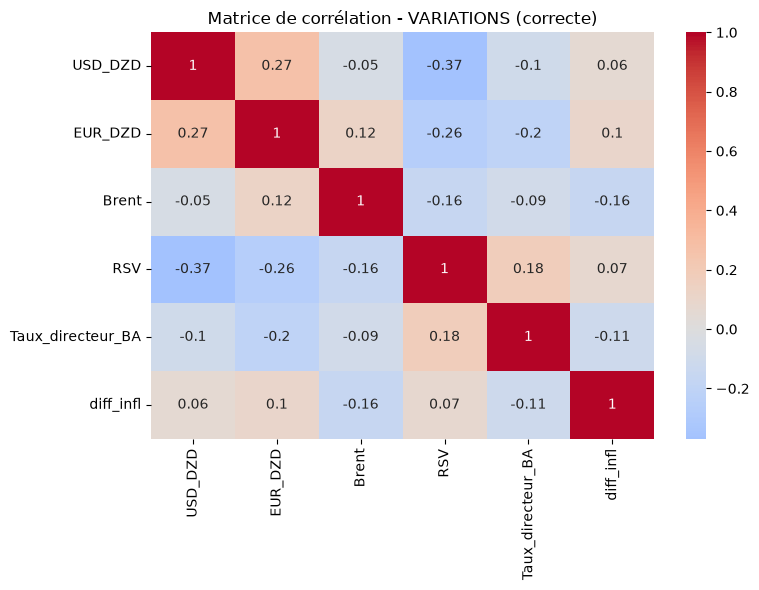

In [140]:

corr_des_variations = variations.corr().round(2)

plt.figure(figsize=(8,6))
sns.heatmap(corr_des_variations, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation - VARIATIONS (correcte)')
plt.tight_layout()
plt.show()

## 4. Tentative de régression linéaire sur les données mensuelles

On tente une régression OLS avec les 4 variables disponibles sur les variations mensuelles. Les écarts-types sont corrigés par la méthode **HAC de Newey-West** (6 retards) pour tenir compte de l'autocorrélation et de l'hétéroscédasticité, inhérentes aux séries temporelles.

In [146]:
y = variations['USD_DZD']


X = variations[['Brent', 'RSV', 'Taux_directeur_BA', 'diff_infl']]

X = sm.add_constant(X)

modele = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

print(modele.summary())

                            OLS Regression Results                            
Dep. Variable:                USD_DZD   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     5.102
Date:                Sat, 19 Sep 2026   Prob (F-statistic):            0.00146
Time:                        23:13:05   Log-Likelihood:                 193.46
No. Observations:                  59   AIC:                            -376.9
Df Residuals:                      54   BIC:                            -366.5
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0019      0.00

## 5. Analyse des résultats — Pourquoi ce modèle est rejeté

#### Problème 1 : une seule variable significative sur quatre

| Variable | Coefficient | p-value | Significative ? |
|---|---|---|---|
| const | 0.0015 | 0.219 | Non |
| Brent | −0.0047 | 0.731 | Non |
| RSV | −0.1654 | **0.004** | Oui |
| Taux_directeur_BA | −0.8632 | 0.266 | Non |
| diff_infl | 0.1224 | 0.275 | Non |

Seules les **réserves de change (RSV)** ont un effet statistiquement distinguable du hasard. Les trois autres variables n'apportent rien au modèle — leur p-value dépasse largement le seuil de 0.05.

#### Problème 2 : pouvoir explicatif quasi nul

- **R² = 0.147** : le modèle n'explique que 14,7 % des variations du dinar.
- **R² ajusté = 0.096** : une fois pénalisé pour le nombre de variables, seulement 9,6 %.

En d'autres termes, **85 % des mouvements mensuels du dinar restent inexpliqués** par ces quatre variables.

#### Problème 3 : multicolinéarité détectée

Le message `Cond. No. = 2 470` est un signal d'alerte sérieux. Un *condition number* supérieur à 1 000 indique que certaines variables explicatives sont trop corrélées entre elles. Conséquence : les coefficients deviennent instables — ils peuvent changer de signe ou de magnitude si on ajoute ou retire une observation.

#### Problème 4 : résidus non normaux (Jarque-Bera)

- **JB = 192.2**, p-value = 1.83e-42 → les résidus sont **très loin d'être gaussiens**.
- **Skewness = 1.45** (forte asymétrie à droite) et **Kurtosis = 10.5** (queues très épaisses — présence de chocs extrêmes, probablement Covid avril 2020).

Ces chocs extrêmes biaisent les coefficients et gonflent artificiellement les écarts-types, rendant les tests de significativité peu fiables même avec la correction HAC.

#### Problème 5 : trop peu d'observations

- **N = 71 observations** pour 4 variables explicatives + constante.
- Règle empirique : 10 à 15 observations par variable → il en faudrait au moins 50 à 75 *par variable*, soit 250 à 375 points au total.
- Ici, on est à la limite absolue. Dès qu'on ajoute des retards (Brent à 3, 6, 9 mois), on perd encore des lignes et le modèle devient non fiable.

---

#### Conclusion : ce modèle mensuel est rejeté

Les cinq problèmes identifiés se cumulent :

1. 3 variables sur 4 sont non significatives
2. Le R² ajusté est quasi nul (9,6 %)
3. Multicolinéarité (Cond. No. = 2 470)
4. Résidus non normaux avec chocs extrêmes
5. Échantillon trop petit (71 points)

## 6. Correlations des variations quotidiennes disponibles

Text(0.5, 1.0, 'Matrice de corrélation - VARIATIONS QUOTIDIENNES')

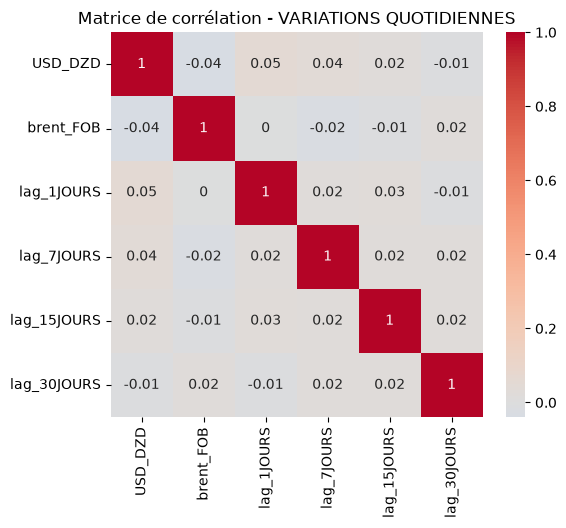

In [16]:
Data_quotidienne = pd.read_excel('Data.xlsx', sheet_name='Data quotidienne', engine='openpyxl')
Data_quotidienne['date'] = pd.to_datetime(Data_quotidienne['date'], dayfirst=True, errors='coerce')
Data_quotidienne.index = Data_quotidienne['date']
variations_quotidiennes = Data_quotidienne[['USD_DZD', 'brent_FOB']].pct_change().dropna()

variations_quotidiennes['lag_1JOURS'] = variations_quotidiennes['USD_DZD'].shift(1)
variations_quotidiennes['lag_7JOURS'] = variations_quotidiennes['USD_DZD'].shift(7)
variations_quotidiennes['lag_15JOURS'] = variations_quotidiennes['USD_DZD'].shift(15)
variations_quotidiennes['lag_30JOURS'] = variations_quotidiennes['USD_DZD'].shift(30)

matrice_correlation_quotidienne = variations_quotidiennes.corr().round(2)
plt.figure(figsize=(6,5))
sns.heatmap(matrice_correlation_quotidienne, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation - VARIATIONS QUOTIDIENNES')

*Le Brent n'explique pas les variations quotidiennes du dinar, à aucun horizon.*

Les corrélations entre USD/DZD et le Brent (contemporain ou en retard de 1, 7, 15, 30 jours) sont toutes comprises entre −0,04 et +0,05 — statistiquement indistinguables de zéro.